<a href="https://colab.research.google.com/github/opherdonchin/BayesShortCourse/blob/main/golf/01_logistic_baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Golf putting 1 — Logistic baseline

Start with the conventional statistical model. The goal is not to make logistic regression “win”; it is to establish a baseline and practice the workflow before introducing golf-specific mechanism.

## Setup

This course pins PyMC and the modular ArviZ packages for reproducibility because their APIs can change across major versions.

In [1]:
%pip install -q \
    "pymc==6.3.2" \
    "arviz-base==1.3.0" \
    "arviz-stats==1.3.2" \
    "arviz-plots[matplotlib]==1.3.1"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.3/608.3 kB 15.5 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 59.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 195.4/195.4 kB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.1/253.1 kB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 58.1 MB/s eta 0:00:0000:01


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymc as pm
import arviz_plots as azp
import arviz_stats as azs

RANDOM_SEED = 20260923
azp.style.use("arviz-variat")

print("PyMC:", pm.__version__)
print("arviz-plots:", azp.__version__)
print("arviz-stats:", azs.__version__)

DATA_BASE = "https://raw.githubusercontent.com/opherdonchin/BayesShortCourse/main/golf/data"
golf = pd.read_csv(f"{DATA_BASE}/berry_1996_putting.csv")
golf["rate"] = golf["made"] / golf["attempts"]

BALL_RADIUS_FT = (1.68 / 2) / 12
CUP_RADIUS_FT = (4.25 / 2) / 12

golf

PyMC: 6.3.2
arviz-plots: 1.3.1
arviz-stats: 1.3.2


,distance_ft,attempts,made,rate
0,2,1443,1346,0.932779
1,3,694,577,0.831412
2,4,455,337,0.740659
3,5,353,208,0.589235
4,6,272,149,0.547794
5,7,256,136,0.531250
6,8,240,111,0.462500
7,9,217,69,0.317972
8,10,200,67,0.335000
9,11,237,75,0.316456


In [3]:
def plot_rate(draws, data, title, *, median_label="median", show_observed=True, ylim=(-0.05, 1.05), show_bounds=False):
    """Plot a probability/rate relationship against continuous putting distance."""
    x = data["distance_ft"].to_numpy()
    curve_dim = next(dim for dim in draws.dims if dim not in ("chain", "draw"))
    order = np.argsort(x)
    draws = draws.isel({curve_dim: order})
    x = x[order]

    median = draws.median(dim=("chain", "draw"))
    interval = draws.azstats.hdi(prob=0.90)

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.fill_between(
        x,
        interval.sel(ci_bound="lower"),
        interval.sel(ci_bound="upper"),
        alpha=0.22,
        label="90% HDI",
    )
    ax.plot(x, median, label=median_label)
    if show_observed:
        ax.scatter(x, data["rate"].to_numpy()[order], s=30, color="black", label="observed")
    if show_bounds:
        ax.axhline(0, color="0.6", linewidth=0.8, linestyle="--")
        ax.axhline(1, color="0.6", linewidth=0.8, linestyle="--")
    ax.set(
        xlabel="Distance from hole (feet)",
        ylabel="Proportion made",
        title=title,
    )
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.legend(fontsize=8, frameon=False)
    return ax

def plot_residuals(idata, data, var_name="p_base", title="Residuals"):
    """Plot observed minus posterior-median mechanistic probability."""
    fitted = idata["posterior"][var_name].median(dim=("chain", "draw")).to_numpy()
    x = data["distance_ft"].to_numpy()
    residual = data["rate"].to_numpy() - fitted
    order = np.argsort(x)

    fig, ax = plt.subplots(figsize=(7, 3.5))
    ax.axhline(0, linestyle="--", linewidth=1)
    ax.plot(x[order], residual[order], marker="o")
    ax.set(
        xlabel="Distance from hole (feet)",
        ylabel="Observed − fitted probability",
        title=title,
    )
    return ax

## Model

$y_j\sim\operatorname{Binomial}(n_j,p_j),\qquad \operatorname{logit}(p_j)=\alpha+\beta x_j.$

This is deliberately generic: distance enters only through a straight line on the log-odds scale.

In [4]:
coords = {"obs_id": golf["distance_ft"].to_numpy()}

with pm.Model(coords=coords) as model:
    distance = pm.Data("distance", golf["distance_ft"].to_numpy(), dims="obs_id")
    attempts = pm.Data("attempts", golf["attempts"].to_numpy(), dims="obs_id")

    intercept = pm.Normal("intercept", mu=0, sigma=3)
    slope = pm.Normal("slope", mu=0, sigma=0.5)

    logit_p = intercept + slope * distance
    p_base = pm.Deterministic(
        "p_base",
        pm.math.sigmoid(logit_p),
        dims="obs_id",
    )

    pm.Binomial(
        "made",
        n=attempts,
        logit_p=logit_p,
        observed=golf["made"].to_numpy(),
        dims="obs_id",
    )

## Prior predictive check

Before fitting, ask what success rates the prior says are plausible across putting distance. The observed rates are shown only as a reference; they do not condition the prior.

In [5]:
with model:
    prior = pm.sample_prior_predictive(
        draws=500,
        var_names=["made"],
        random_seed=RANDOM_SEED,
    )

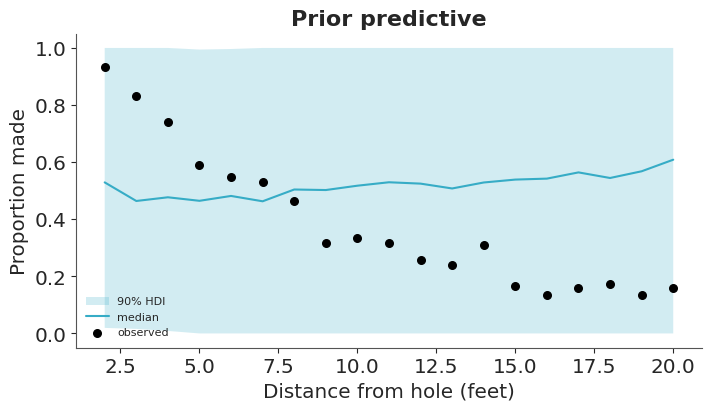

In [6]:
plot_rate(
    prior["prior_predictive"]["made"] / golf["attempts"].to_numpy(),
    golf,
    "Prior predictive",
);

## Fit and diagnose

Do not interpret the scientific fit until the sampler diagnostics are acceptable.

In [7]:
with model:
    idata = pm.sample(
        draws=1000,
        tune=1500,
        chains=4,
        target_accept=0.9,
        random_seed=RANDOM_SEED,
    )

print("Divergences:", int(idata["sample_stats"]["diverging"].sum().item()))
azs.summary(
    idata,
    var_names=['intercept', 'slope'],
    ci_prob=0.90,
    ci_kind="hdi",
    round_to=2,
)

Output()

Divergences: 0


,mean,sd,hdi90_lb,hdi90_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
intercept,2.23,0.06,2.13,2.32,1090.79,1234.98,1.0,0.0,0.0
slope,-0.26,0.01,-0.27,-0.24,1040.40,1150.85,1.0,0.0,0.0


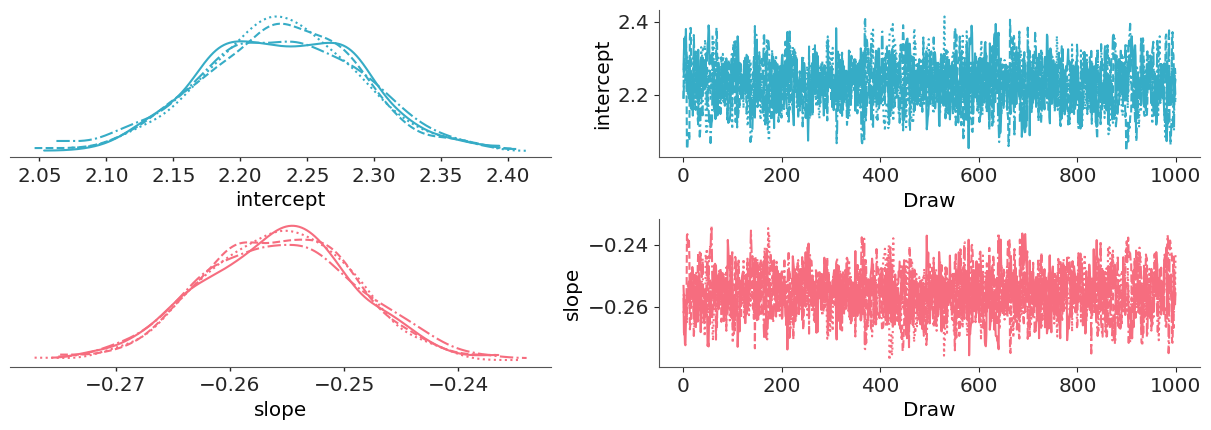

In [8]:
azp.plot_trace_dist(idata, var_names=['intercept', 'slope']);

## Posterior fit

This plot shows posterior uncertainty in the continuous mechanistic success-probability relationship $p_{base}(x)$. It does not include the additional variation in newly observed successes.

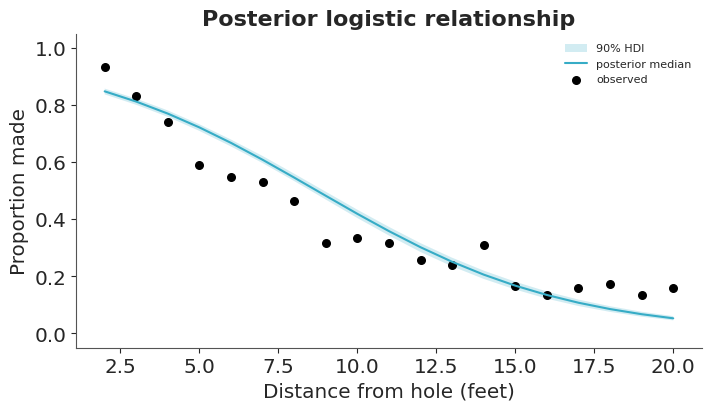

In [9]:
plot_rate(
    idata["posterior"]["p_base"],
    golf,
    "Posterior logistic relationship",
    median_label="posterior median",
);

## Posterior predictive check

Now generate new outcomes at the same putting distances from the fitted model. This uses the same graphical grammar as the prior predictive check; the difference is that these predictions are conditioned on the observed data.

In [10]:
with model:
    pm.sample_posterior_predictive(
        idata,
        var_names=["made"],
        extend_inferencedata=True,
        random_seed=RANDOM_SEED,
    )

Output()

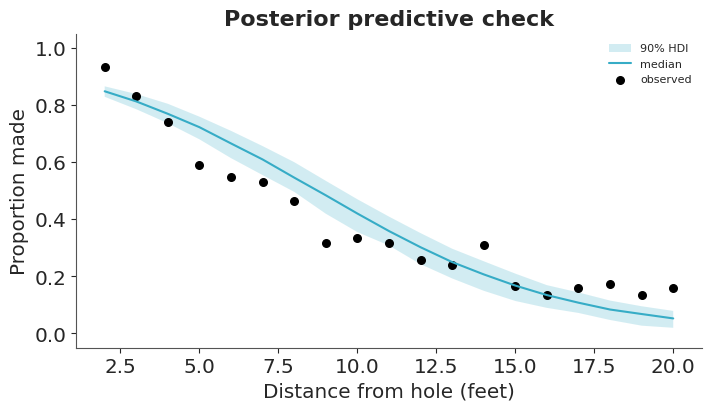

In [11]:
plot_rate(
    idata["posterior_predictive"]["made"] / golf["attempts"].to_numpy(),
    golf,
    "Posterior predictive check",
);

## Model criticism

These residuals compare the observed rates with the posterior-median mechanistic relationship $p_{base}(x)$. They are a check for systematic structure in the mechanism, not a posterior predictive interval.

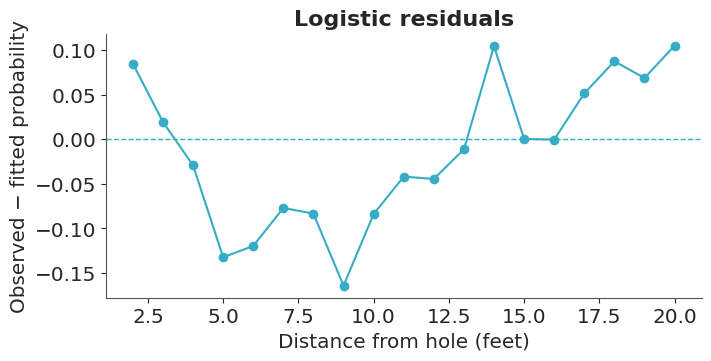

In [12]:
plot_residuals(idata, golf, var_name="p_base", title="Logistic residuals");

## Decision: revise the model

The logistic curve is a useful baseline, but it has no representation of the geometry of putting. Even if its in-sample fit were tolerable, its extrapolation is driven by the arbitrary logit-linear form. **Next notebook:** replace the generic curve with a mechanism-based angle model.